In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms
import scipy.stats as stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns

from previoABC import flujo_previo_ABC
from funciones import comprobar_dimensiones_ubic
from funciones2 import *

In [2]:
data_ABC = flujo_previo_ABC(region = "Los Santos", print_comprobacion_dimensiones = True)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 chirps   No. Observations:                 8208
Model:                            GLM   Df Residuals:                     8199
Model Family:                   Gamma   Df Model:                            8
Link Function:                    log   Scale:                         0.33380
Method:                          IRLS   Log-Likelihood:                -45944.
Date:                Thu, 18 Jun 2026   Deviance:                       2201.7
Time:                        23:47:39   Pearson chi2:                 2.74e+03
No. Iterations:                    19   Pseudo R-squ. (CS):             0.9201
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9461      0.009    527.766      0.0

In [3]:
# Calibración de modelos mediante Approximate Bayesian Computation (ABC)
dt_errores = pd.read_parquet('20260618_santos.parquet')

In [4]:
datos_santos_train = data_ABC["train"]
datos_santos_train_pivot = data_ABC["train_pivot"]
datos_santos_test = data_ABC["test"]
nsites_santos = data_ABC["nsites"]
nsites_training_santos = data_ABC["nsites_training"]
GLM_santos = data_ABC["GLM"]
ubic_santos = data_ABC["ubic"]
ubic_training_santos = data_ABC["ubic_training"]
dist_mat_santos = data_ABC["dist_mat"]
dist_mat_training_santos = data_ABC["dist_mat_training"]
m_training_santos = data_ABC["m_training"]

In [5]:
# Fecha corte para training
fecha_corte_2018 = pd.to_datetime('2018-12-31')

# Identificar Y_pred
# Restar 1 que fue añadido anteriormente
datos_santos_train["Y_pred"] = datos_santos_train["Y_plus_pred"] - 1
datos_santos_test["Y_pred"] = datos_santos_test["Y_plus_pred"] - 1

In [6]:
# Modificaciones para generar simulaciones en testing
datos_santos_test2 = datos_santos_test[datos_santos_test['date'] > fecha_corte_2018]
datos_santos_test2_pivot = datos_santos_test2.pivot(index='date', columns=['lat','lon'], values='exp_residuos')
m_testing_santos = int(len(datos_santos_test2)/nsites_santos)

In [7]:
comprobar_dimensiones_ubic(ubic_santos, datos_santos_test2_pivot)

True

In [8]:
def plot_modelo_GLM_global(datos):
    a = datos
    a_real = a["chirps"]
    a_pred = a["Y_pred"] 

    plt.figure()
    plt.scatter(a_real, a_pred)
    plt.plot([a_real.min(), a_real.max()],[a_real.min(), a_real.max()], linestyle='--')
    plt.xlabel("Y chirps")
    plt.ylabel("Y pred")
    plt.title("Y chirps vs Y pred")
    plt.show()

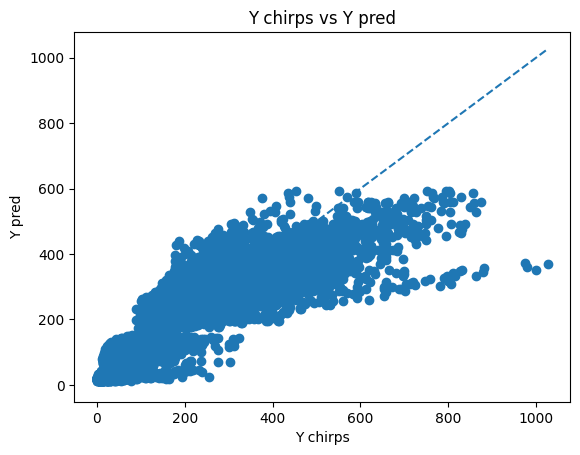

In [9]:
# Training
plot_modelo_GLM_global(datos_santos_train)

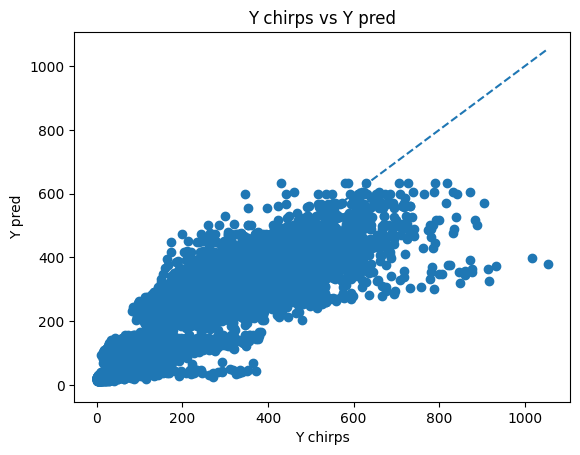

In [10]:
# Testing
plot_modelo_GLM_global(datos_santos_test)

In [11]:
def plot_modelo_GLM_ubic(datos, ubic, max_plots=10):
    count = 0

    for _, row in ubic.iterrows():
        lat, lon = row['lat'], row['lon']
        
        a = datos[(datos['lat'] == lat) & (datos['lon'] == lon)].copy()

        # 1. Serie temporal
        plt.plot(a["date"], a["chirps"], label="chirps")
        plt.plot(a["date"], a["Y_pred"], label="Y_pred")
        plt.title(f"Lat={lat}, Lon={lon}")
        plt.ylabel("Precipitaciones")
        plt.legend()
        plt.grid()

        plt.tight_layout()
        plt.show()
    
        count += 1
        if count >= max_plots:
            break

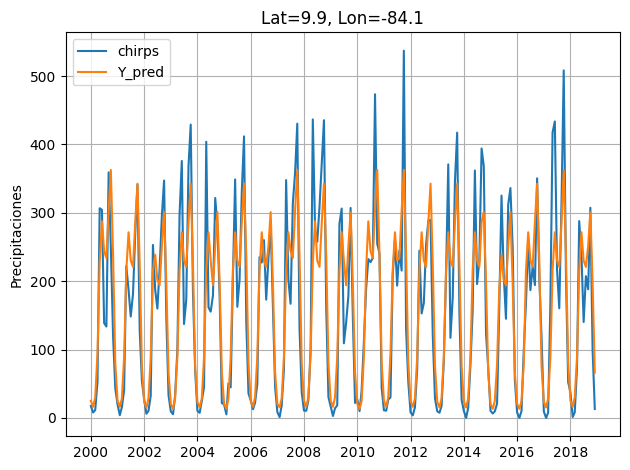

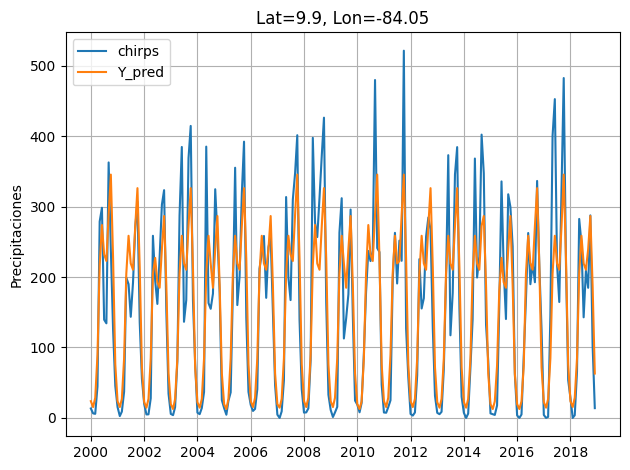

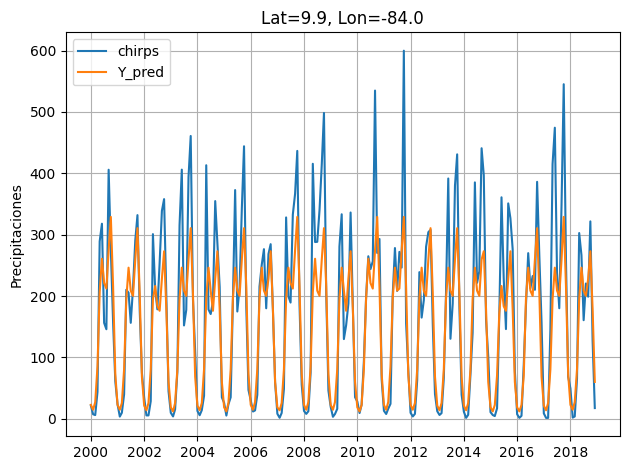

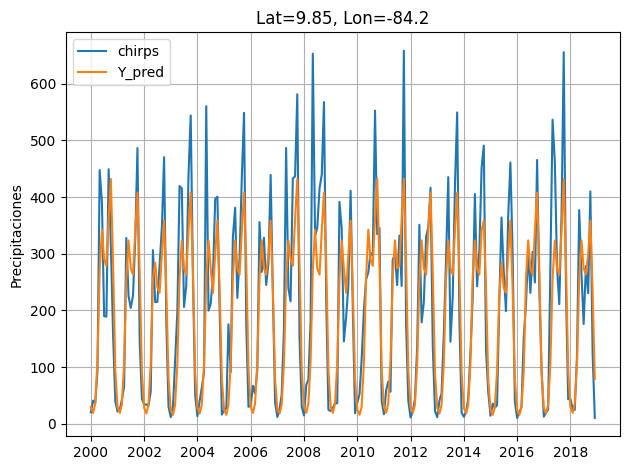

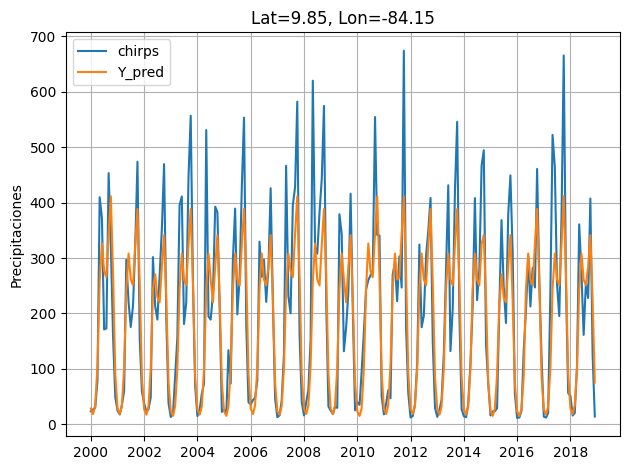

In [12]:
# Training
plot_modelo_GLM_ubic(datos_santos_train, ubic_training_santos, 5)

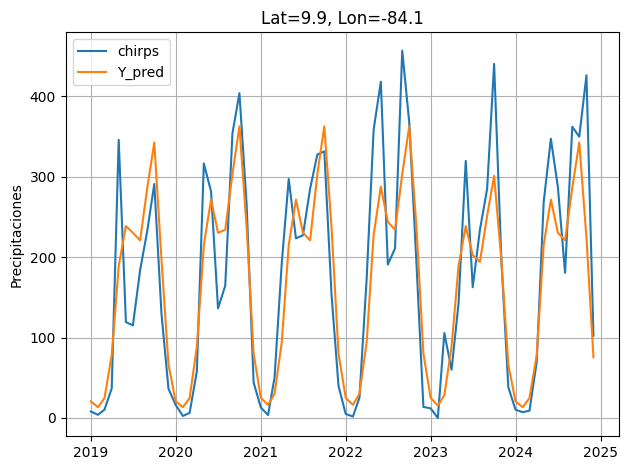

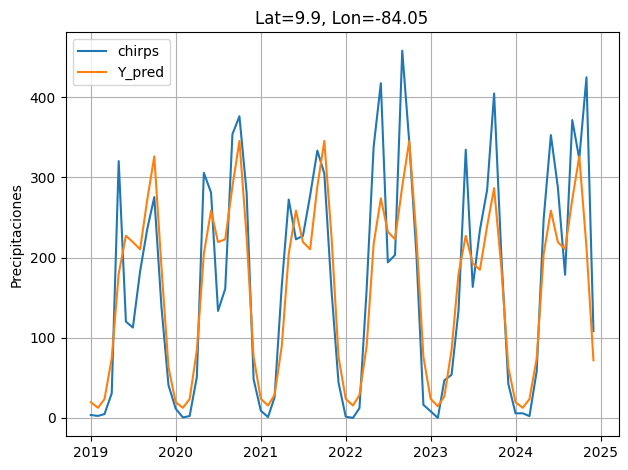

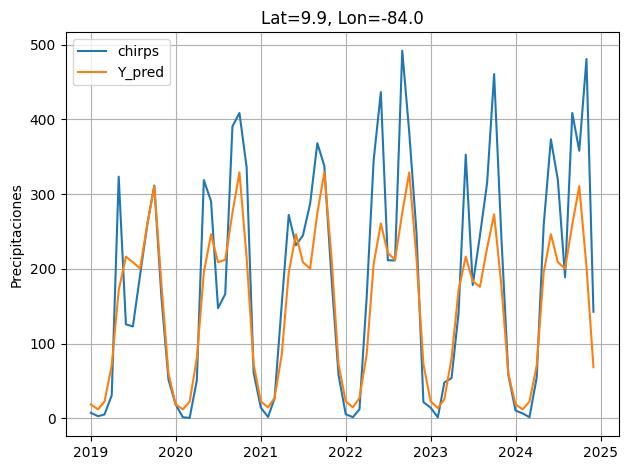

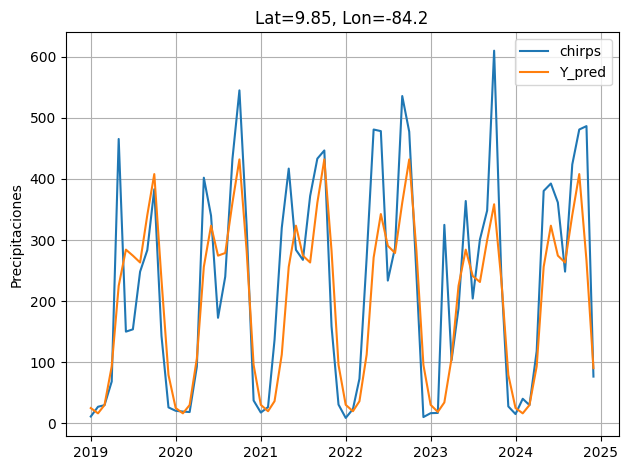

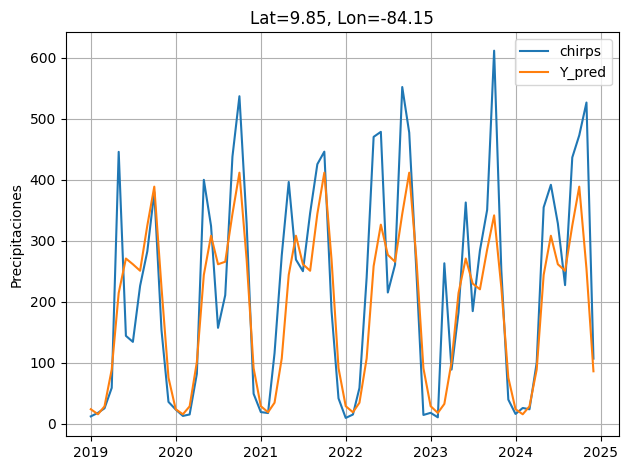

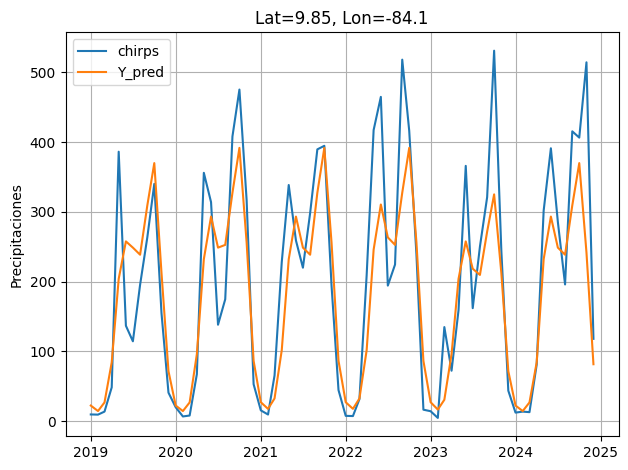

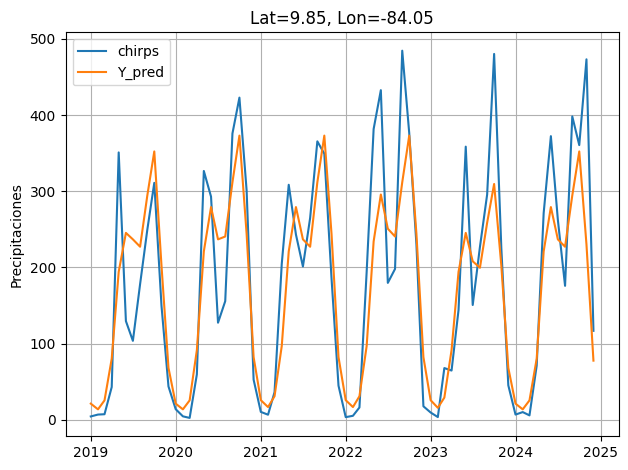

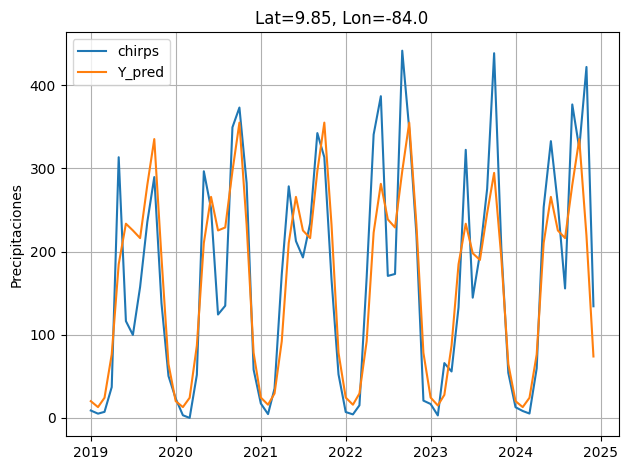

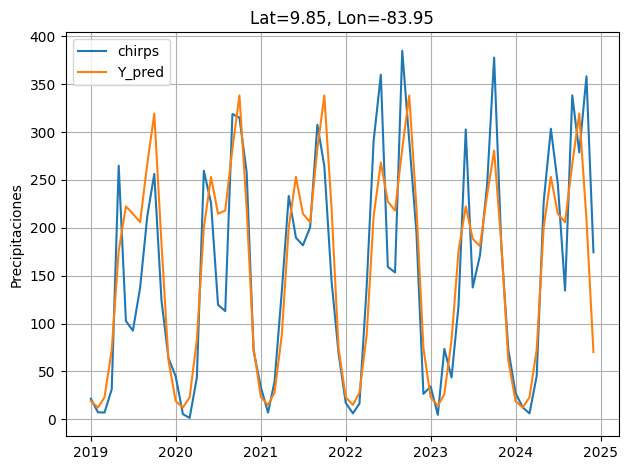

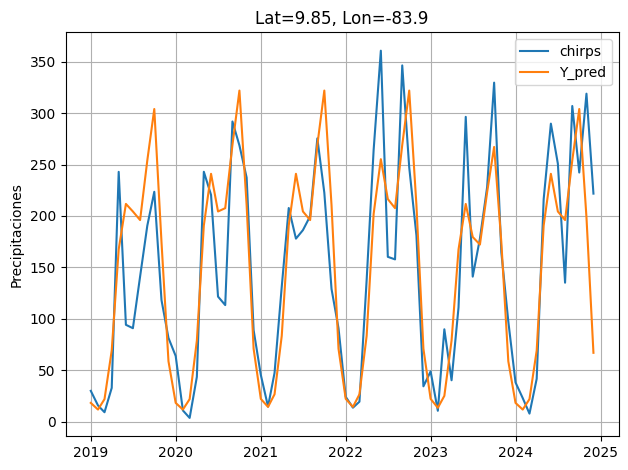

In [13]:
# Testing
plot_modelo_GLM_ubic(datos_santos_test, ubic_santos, 10) # nsites_santos)

In [14]:
# Definir mejor D y M
D_corrida, M_corrida = seleccionar_mejor_modelo(dt_errores, sort_by = 'mean_errorMSE', posicion_n_ranking = 0)
print(D_corrida, M_corrida)

D4 M1


In [15]:
resumen_errores(dt_errores, sort_by = 'mean_errorMSE')

,modelo,covariables,mean_errorSWD,sd_errorSWD,mean_errorMSE,sd_errorMSE,min_errorSWD,max_errorSWD,min_errorMSE,max_errorMSE,iqr_SWD,iqr_MSE,p25_SWD,p25_MSE,p75_SWD,p75_MSE,n
1,D4,M1,2.042585,8.190646,1.523435e+04,2.178385e+06,0.148951,1832.251665,0.446070,6.026432e+08,1.981397,86.366466,0.641372,2.611401,2.622770,88.977867,100000
0,D3,M1,0.862001,10.196023,3.745414e+04,1.124365e+07,0.149013,3102.938611,0.440745,3.554238e+09,0.477465,12.019340,0.441152,1.704185,0.918617,13.723525,100000
2,D5,M1,1.158934,11.500690,4.856034e+04,1.331237e+07,0.149705,3374.457428,0.480219,4.203624e+09,0.288495,22.170739,0.752959,2.391867,1.041454,24.562606,100000
5,D8,M1,3.212297,15.074493,7.947847e+04,8.969076e+06,0.150309,2401.373058,0.492297,2.011153e+09,1.627689,257.976129,1.643646,21.034323,3.271335,279.010452,100000
4,D7,M1,2.695021,42.579152,6.383717e+05,9.246494e+07,0.150169,7758.060818,0.491810,2.521273e+10,1.539119,158.545148,0.955355,8.325010,2.494474,166.870158,100000
3,D6,M1,3.392971,298.801399,3.048203e+07,9.603376e+09,0.149302,94314.881714,0.491584,3.036848e+12,1.546385,160.754991,0.950161,8.187927,2.496547,168.942918,100000


In [16]:
def plot_simulaciones_exp_errores_vs_real(datos_pivot, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida):
    exp_simulacion_errores = corrida_simulacion_exp_errores(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_pivot = datos_pivot)
    serie_simulaciones_promedio = exp_simulacion_errores.mean(axis=1)
    serie_original_exp_errores = datos_pivot.values.mean(axis=1)
    fechas = datos_pivot.index

    plt.plot(fechas, serie_simulaciones_promedio, label = "Simulaciones (sobre exp_errores)", color = "orange")
    plt.plot(fechas, serie_original_exp_errores, label = "Datos originales", color = "steelblue")
    plt.xlabel("Mes")
    plt.ylabel("")
    plt.title("Serie temporal de exp(errores)")
    plt.grid()
    plt.legend()
    plt.show()

Calibración GLM:: MSE: 0.53, SWD: 0.16, phi12: -0.5602920723892072, sigma12: 0.008151624764258902 phi: -0.2168238025879078, sigma: 1.7845733522190925, beta3: 5.91636692432745, rho: 0.723131264802799
Simulación:: MSE: 0.59, MAE: 0.52, SWD: 0.15


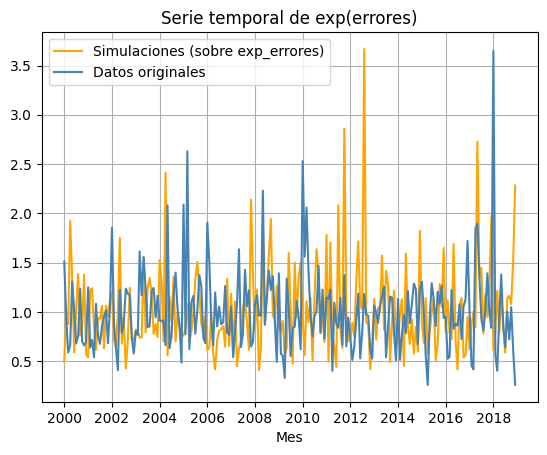

In [17]:
# Training
plot_simulaciones_exp_errores_vs_real(datos_santos_train_pivot, m_training_santos, nsites_training_santos, dist_mat_training_santos)

Calibración GLM:: MSE: 0.54, SWD: 0.16, phi12: 0.05770173806724721, sigma12: 0.0891785284495279 phi: 0.3248838684022918, sigma: 0.9723925794303924, beta3: 7.291245764147527, rho: 0.5232058047286514
Simulación:: MSE: 0.69, MAE: 0.55, SWD: 0.19


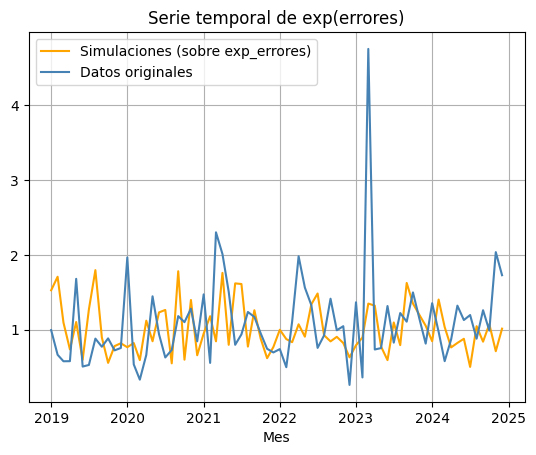

In [18]:
# Testing
plot_simulaciones_exp_errores_vs_real(datos_santos_test2_pivot, m_testing_santos, nsites_santos, dist_mat_santos)

In [19]:
def plot_simulaciones_vs_real(datos_prepivot, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida):
    simulaciones = corrida_simulacion_precipitaciones(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_prepivot = datos_prepivot)
    simulaciones_promedio = simulaciones.mean(axis=1)
    chirps_promedio = datos_prepivot.pivot(index='date', columns=['lat','lon'], values='chirps').values.mean(axis=1)
    fechas = datos_prepivot["date"].drop_duplicates().sort_values()

    metricas_error_presimulaciones(datos_prepivot)
    metricas_error_simulaciones(simulaciones, datos_prepivot)

    plt.plot(fechas, simulaciones_promedio, label = "Simulaciones", color = "orange")
    plt.plot(fechas, chirps_promedio, label = "Datos originales", color = "steelblue")
    plt.xlabel("Mes")
    plt.ylabel("mm")
    plt.title("Precipitaciones mensuales promedio")
    plt.grid()
    plt.legend()
    plt.show()

Calibración GLM:: MSE: 0.47, SWD: 0.16, phi12: -0.44618971708267724, sigma12: 0.002008186867195283 phi: -0.62016279058952, sigma: 0.7324880919033259, beta3: 6.417501287794043, rho: 0.5952819772222435
Media error simulado: 0.9670094907723202
Media error real: lat   lon   
9.90  -84.10    0.836611
      -84.05    0.809524
      -84.00    0.964210
9.85  -84.20    1.117796
      -84.15    1.067149
      -84.10    0.927443
      -84.05    0.847342
      -84.00    0.864205
      -83.95    0.963942
      -83.90    1.130633
9.80  -84.25    1.104340
      -84.20    1.048154
      -84.10    0.918121
      -84.05    0.813949
      -83.95    0.933109
      -83.90    1.296717
      -83.85    1.697170
9.75  -84.25    1.104136
      -84.20    1.097974
      -84.15    1.092903
      -84.00    0.762124
9.70  -84.25    1.079001
      -84.10    1.041929
      -84.00    0.790010
      -83.95    0.848329
9.65  -84.20    1.096771
      -84.15    1.117719
      -84.10    0.997133
      -84.05    0.870324
   

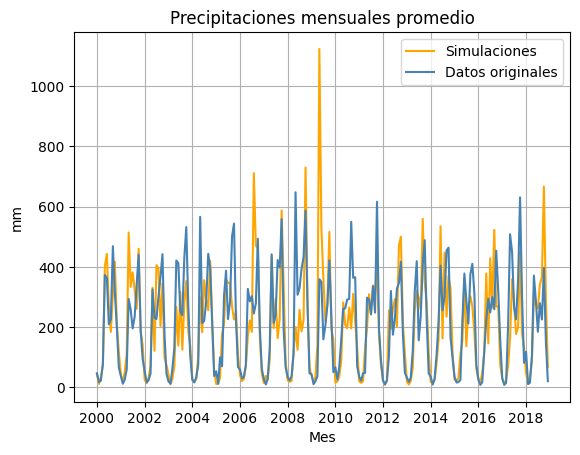

In [21]:
# Training
plot_simulaciones_vs_real(datos_santos_train, m_training_santos, nsites_training_santos, dist_mat_training_santos)

Calibración GLM:: MSE: 0.52, SWD: 0.18, phi12: -0.727299507669764, sigma12: 0.011999034865445735 phi: 0.6228491426665091, sigma: 0.8156751212754646, beta3: 7.463750559176096, rho: 0.08992667108520914
Media error simulado: 0.9916069528565468
Media error real: lat   lon   
9.90  -84.10    0.930517
      -84.05    0.880336
      -84.00    1.021447
9.85  -84.20    1.233097
      -84.15    1.189496
      -84.10    1.020404
      -84.05    0.918618
      -84.00    0.912901
      -83.95    0.971253
      -83.90    1.120271
9.80  -84.25    1.244461
      -84.20    1.123061
      -84.15    1.101410
      -84.10    0.987343
      -84.05    0.868908
      -84.00    0.808812
      -83.95    0.937452
      -83.90    1.302023
      -83.85    1.709219
9.75  -84.30    1.300306
      -84.25    1.282490
      -84.20    1.234557
      -84.15    1.231028
      -84.10    1.097075
      -84.05    0.923258
      -84.00    0.814255
9.70  -84.30    1.193308
      -84.25    1.279442
      -84.15    1.334912
   

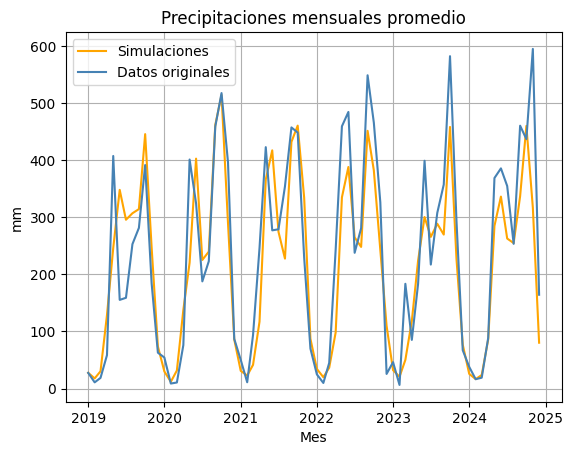

In [22]:
# Testing
plot_simulaciones_vs_real(datos_santos_test2, m_testing_santos, nsites_santos, dist_mat_santos)

In [29]:
def plot_qqplot_modelo_precipitaciones(datos_prepivot, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida):
    simulaciones = corrida_simulacion_precipitaciones(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_prepivot = datos_prepivot)
    datos_pivot = datos_prepivot.pivot(index='date', columns=['lat','lon'], values='chirps')
    simulaciones_coords = asignar_coords_a_simulacion(simulaciones, datos_pivot)
    
    # Extraer vectores
    obs = datos_prepivot["chirps"].values
    sim = simulaciones_coords["simulaciones"].values

    # QQ
    q = np.linspace(0.01, 0.99, 100)
    obs_q = np.quantile(obs, q)
    sim_q = np.quantile(sim, q)

    # Plot
    plt.figure(figsize=(6,6))
    plt.scatter(obs_q, sim_q)

    # Identidad
    min_val = min(obs_q.min(), sim_q.min())
    max_val = max(obs_q.max(), sim_q.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Cuantiles observados")
    plt.ylabel("Cuantiles simulados")
    plt.title("QQ-plot global")
    plt.grid()
    plt.show()

Calibración GLM:: MSE: 0.52, SWD: 0.16, phi12: 0.6531729183942178, sigma12: 0.12109834684372744 phi: 0.6222662710433805, sigma: 0.6923357606704452, beta3: 7.074399879031534, rho: 0.8922811774986098
Media error simulado: 0.9962221471571592
Media error real: lat   lon   
9.90  -84.10    0.836611
      -84.05    0.809524
      -84.00    0.964210
9.85  -84.20    1.117796
      -84.15    1.067149
      -84.10    0.927443
      -84.05    0.847342
      -84.00    0.864205
      -83.95    0.963942
      -83.90    1.130633
9.80  -84.25    1.104340
      -84.20    1.048154
      -84.10    0.918121
      -84.05    0.813949
      -83.95    0.933109
      -83.90    1.296717
      -83.85    1.697170
9.75  -84.25    1.104136
      -84.20    1.097974
      -84.15    1.092903
      -84.00    0.762124
9.70  -84.25    1.079001
      -84.10    1.041929
      -84.00    0.790010
      -83.95    0.848329
9.65  -84.20    1.096771
      -84.15    1.117719
      -84.10    0.997133
      -84.05    0.870324
     

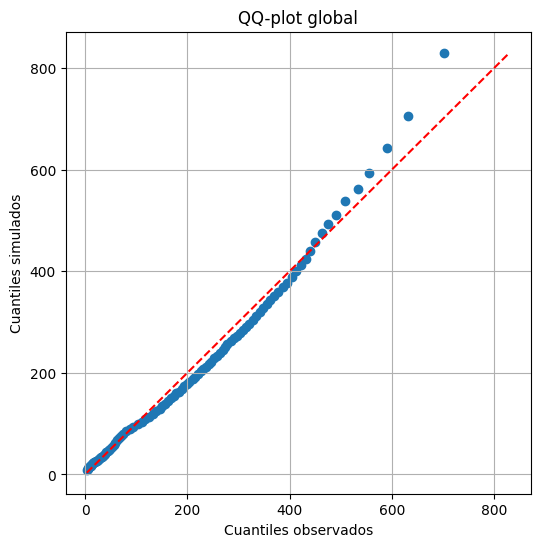

In [30]:
# Training
plot_qqplot_modelo_precipitaciones(datos_santos_train, m_training_santos, nsites_training_santos, dist_mat_training_santos, D_corrida, M_corrida)

Calibración GLM:: MSE: 0.55, SWD: 0.16, phi12: -0.3383973698817684, sigma12: 0.10007635002588189 phi: 0.7802102855696323, sigma: 1.6509399718302955, beta3: 6.26606303342769, rho: 0.5882929556657795
Media error simulado: 1.02190815227437
Media error real: lat   lon   
9.90  -84.10    0.930517
      -84.05    0.880336
      -84.00    1.021447
9.85  -84.20    1.233097
      -84.15    1.189496
      -84.10    1.020404
      -84.05    0.918618
      -84.00    0.912901
      -83.95    0.971253
      -83.90    1.120271
9.80  -84.25    1.244461
      -84.20    1.123061
      -84.15    1.101410
      -84.10    0.987343
      -84.05    0.868908
      -84.00    0.808812
      -83.95    0.937452
      -83.90    1.302023
      -83.85    1.709219
9.75  -84.30    1.300306
      -84.25    1.282490
      -84.20    1.234557
      -84.15    1.231028
      -84.10    1.097075
      -84.05    0.923258
      -84.00    0.814255
9.70  -84.30    1.193308
      -84.25    1.279442
      -84.15    1.334912
      -

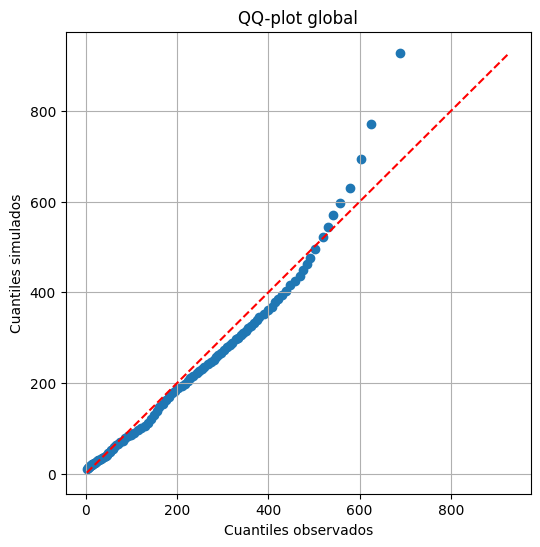

In [31]:
# Testing
plot_qqplot_modelo_precipitaciones(datos_santos_test2, m_testing_santos, nsites_santos, dist_mat_santos, D_corrida, M_corrida)

In [32]:
def plot_modelo_precipitaciones_ubic(datos_prepivot, ubic, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida, max_plots=15):
    simulaciones = corrida_simulacion_precipitaciones(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_prepivot = datos_prepivot)
    datos_pivot = datos_prepivot.pivot(index='date', columns=['lat','lon'], values='chirps')
    simulaciones_coords = asignar_coords_a_simulacion(simulaciones,datos_pivot)

    count = 0
    for _, row in ubic.iterrows():
        lat, lon = row['lat'], row['lon']

        a = datos_prepivot[(datos_prepivot['lat'] == lat) & (datos_prepivot['lon'] == lon)].copy()
        b = simulaciones_coords[(simulaciones_coords['lat'] == lat) & (simulaciones_coords['lon'] == lon)].copy()
        df_plot = a.merge(b, on=['date', 'lat', 'lon'])
        df_plot = df_plot.sort_values("date")

        # Crear figura
        fig, axes = plt.subplots(2, 1, figsize=(10, 8))

        # 1. Serie temporal
        axes[0].plot(df_plot["date"], df_plot["chirps"], label="Observado")
        axes[0].plot(df_plot["date"], df_plot["simulaciones"], label="Simulaciones")
        axes[0].set_title(f"Lat={lat}, Lon={lon}")
        axes[0].set_ylabel("Precipitaciones")
        axes[0].legend()
        axes[0].grid()

        # 2. QQ-plot
        q = np.linspace(0.01, 0.99, 50)

        obs_q = np.quantile(df_plot["chirps"], q)
        sim_q = np.quantile(df_plot["simulaciones"], q)

        axes[1].scatter(obs_q, sim_q)

        min_val = min(obs_q.min(), sim_q.min())
        max_val = max(obs_q.max(), sim_q.max())

        axes[1].plot([min_val, max_val], [min_val, max_val], 'r--')

        axes[1].set_title("QQ-plot (cuantiles)")
        axes[1].set_xlabel("Observado")
        axes[1].set_ylabel("Simulaciones")
        axes[1].grid()

        plt.tight_layout()
        plt.show()

        count += 1
        if count >= max_plots:
            break

Calibración GLM:: MSE: 0.55, SWD: 0.16, phi12: -0.6545073916183022, sigma12: 0.08109652310977467 phi: 0.06564985886426777, sigma: 2.959568341252837, beta3: 7.182634548112484, rho: 0.8655736079069517
Media error simulado: 0.9692005580863761
Media error real: lat   lon   
9.90  -84.10    0.836611
      -84.05    0.809524
      -84.00    0.964210
9.85  -84.20    1.117796
      -84.15    1.067149
      -84.10    0.927443
      -84.05    0.847342
      -84.00    0.864205
      -83.95    0.963942
      -83.90    1.130633
9.80  -84.25    1.104340
      -84.20    1.048154
      -84.10    0.918121
      -84.05    0.813949
      -83.95    0.933109
      -83.90    1.296717
      -83.85    1.697170
9.75  -84.25    1.104136
      -84.20    1.097974
      -84.15    1.092903
      -84.00    0.762124
9.70  -84.25    1.079001
      -84.10    1.041929
      -84.00    0.790010
      -83.95    0.848329
9.65  -84.20    1.096771
      -84.15    1.117719
      -84.10    0.997133
      -84.05    0.870324
    

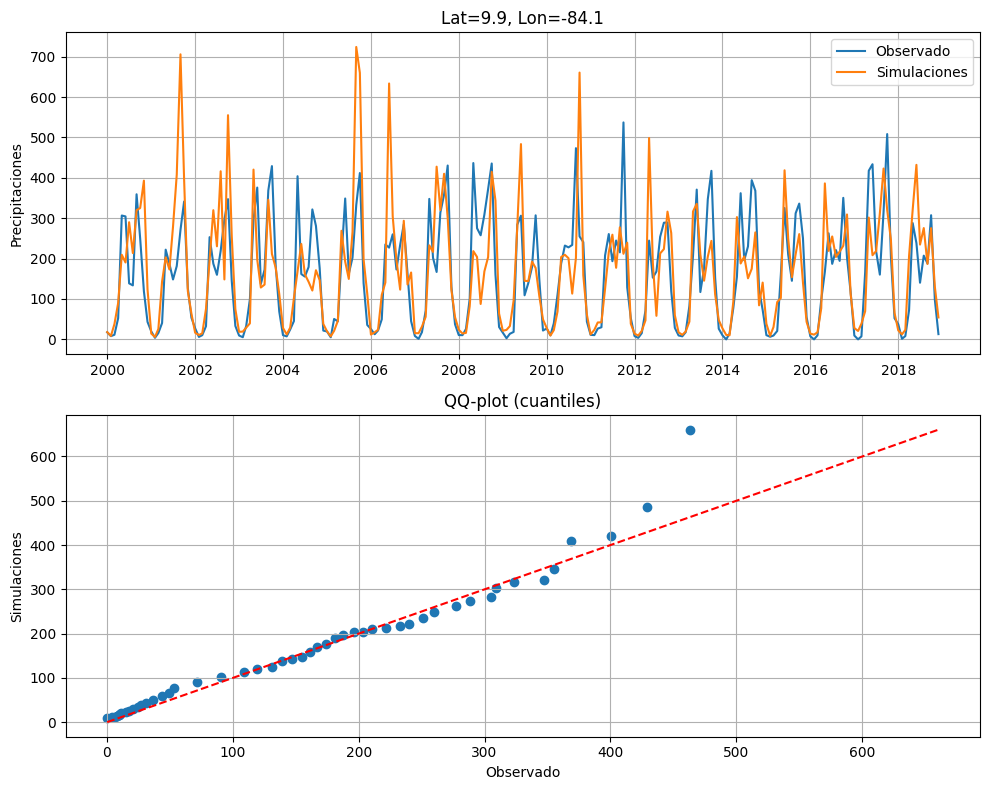

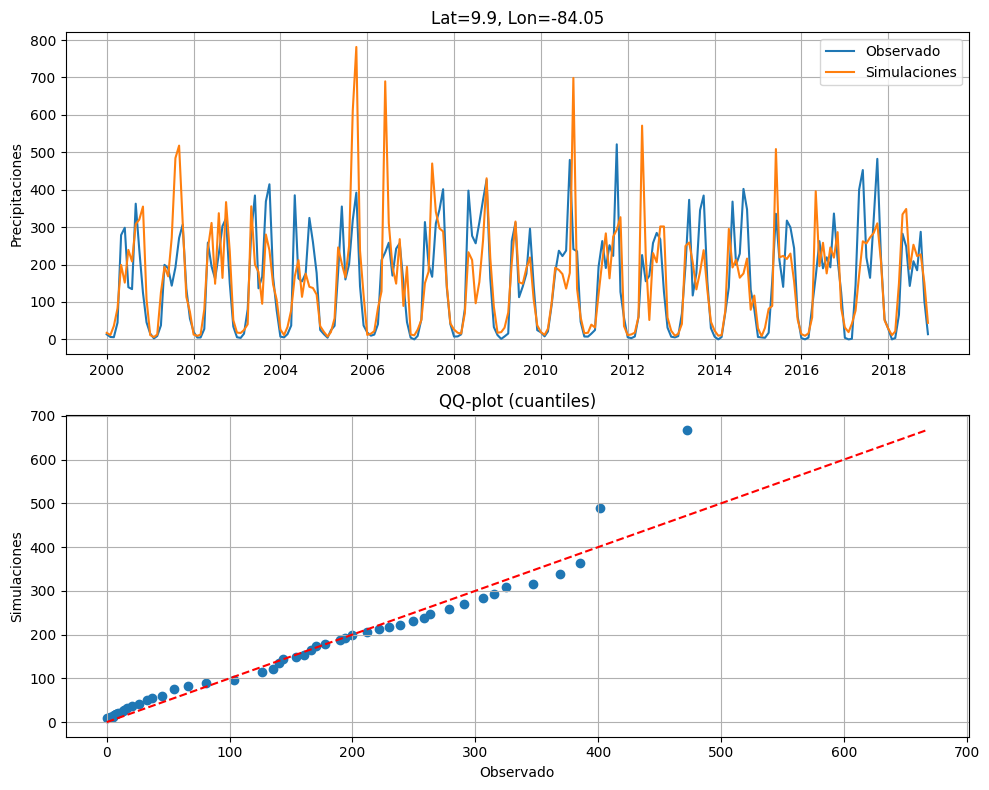

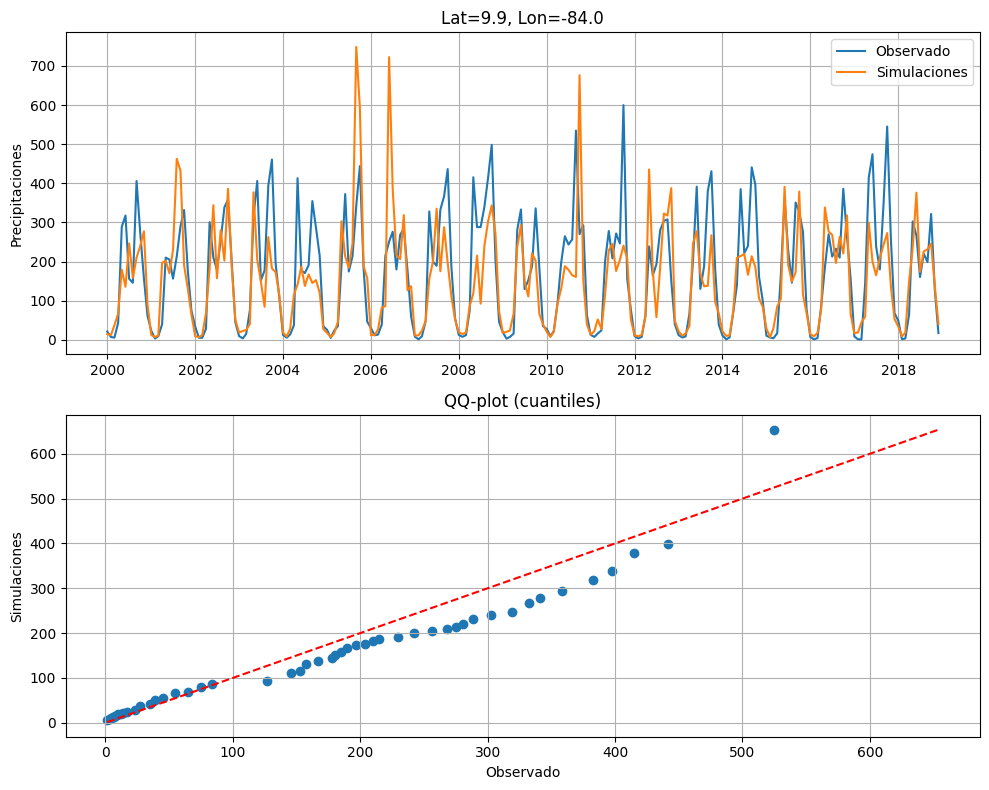

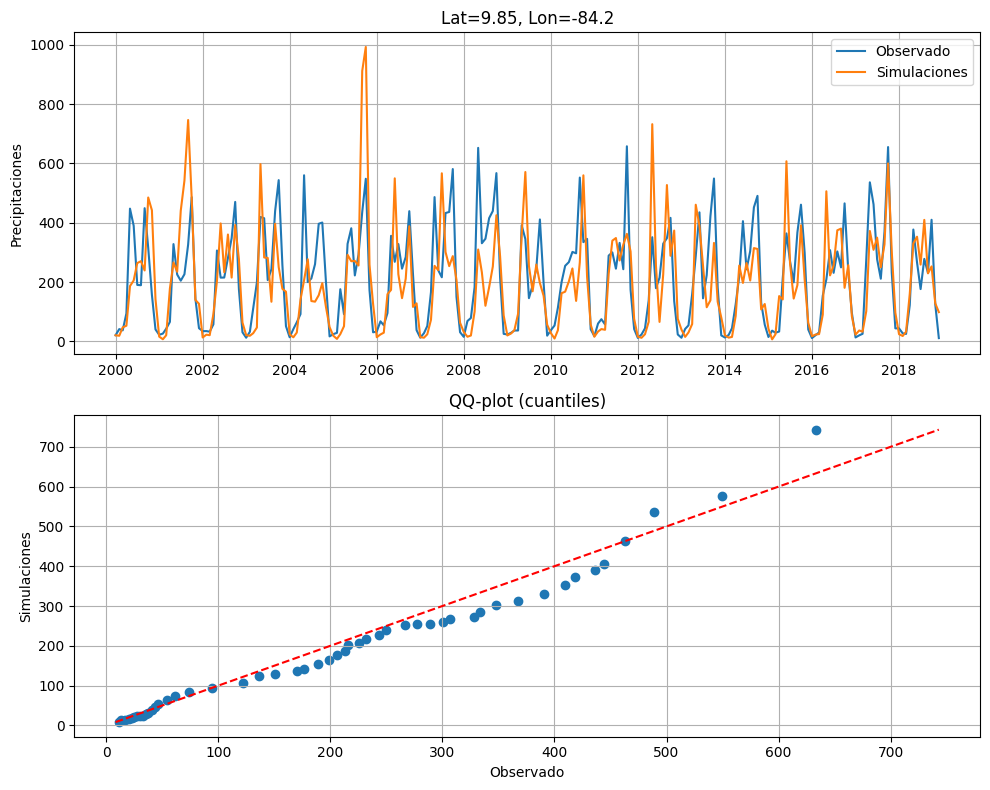

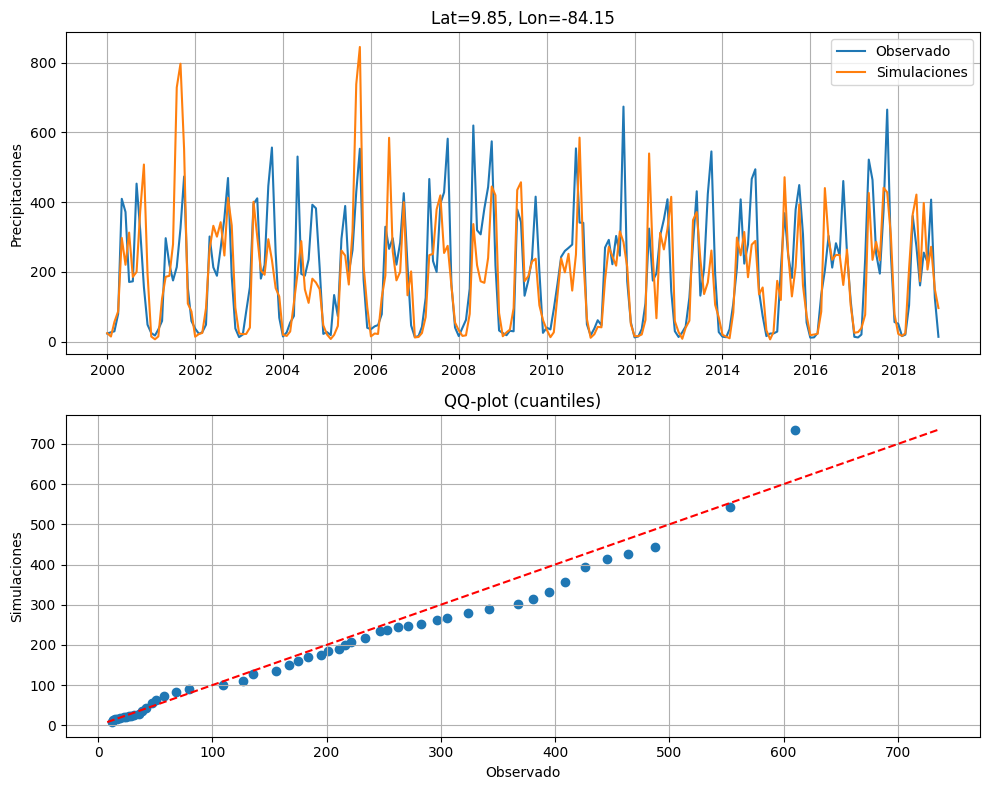

In [33]:
# Training
plot_modelo_precipitaciones_ubic(datos_santos_train, ubic_training_santos, m_training_santos, nsites_training_santos, dist_mat_training_santos, D_corrida, M_corrida, max_plots = 5)

Calibración GLM:: MSE: 0.52, SWD: 0.20, phi12: -0.5484581892729583, sigma12: 0.07577406576867485 phi: 0.7546039279647933, sigma: 0.5325606012559461, beta3: 7.499764184346575, rho: 0.03463103953472129
Media error simulado: 1.003327953706868
Media error real: lat   lon   
9.90  -84.10    0.930517
      -84.05    0.880336
      -84.00    1.021447
9.85  -84.20    1.233097
      -84.15    1.189496
      -84.10    1.020404
      -84.05    0.918618
      -84.00    0.912901
      -83.95    0.971253
      -83.90    1.120271
9.80  -84.25    1.244461
      -84.20    1.123061
      -84.15    1.101410
      -84.10    0.987343
      -84.05    0.868908
      -84.00    0.808812
      -83.95    0.937452
      -83.90    1.302023
      -83.85    1.709219
9.75  -84.30    1.300306
      -84.25    1.282490
      -84.20    1.234557
      -84.15    1.231028
      -84.10    1.097075
      -84.05    0.923258
      -84.00    0.814255
9.70  -84.30    1.193308
      -84.25    1.279442
      -84.15    1.334912
    

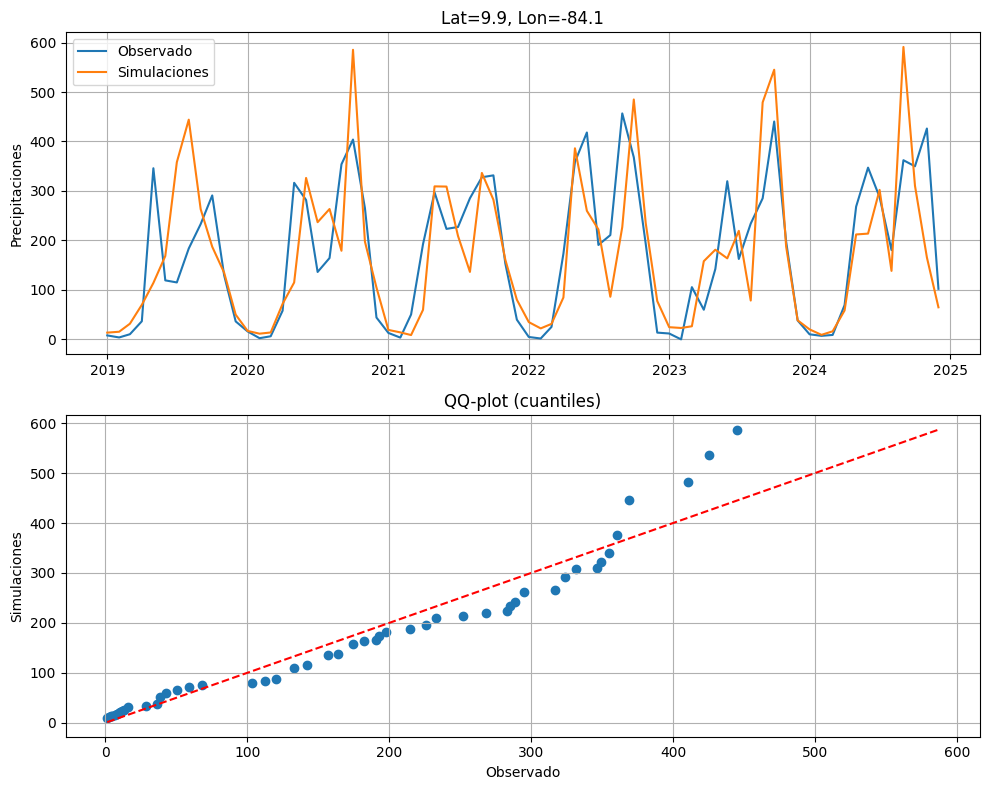

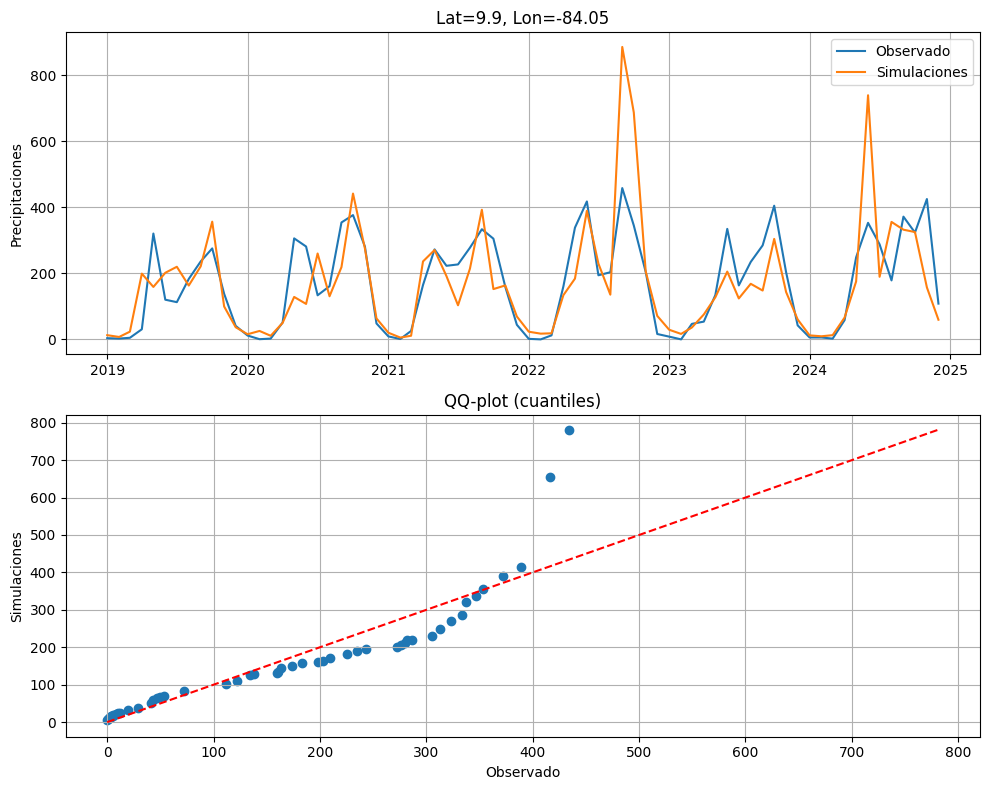

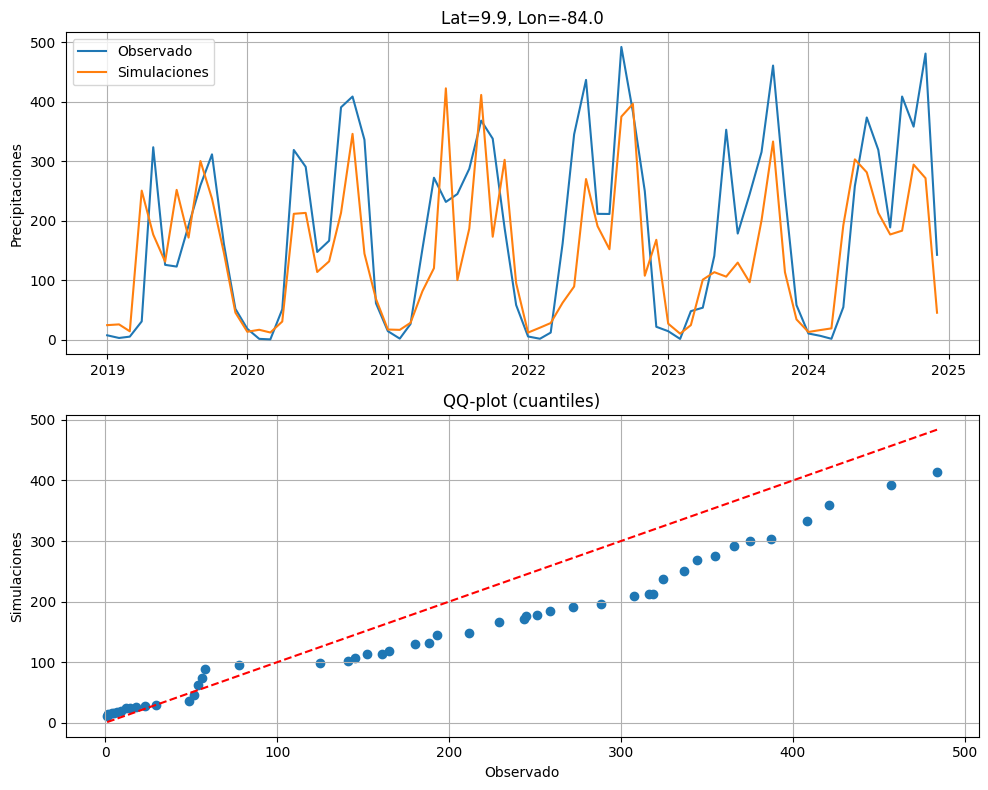

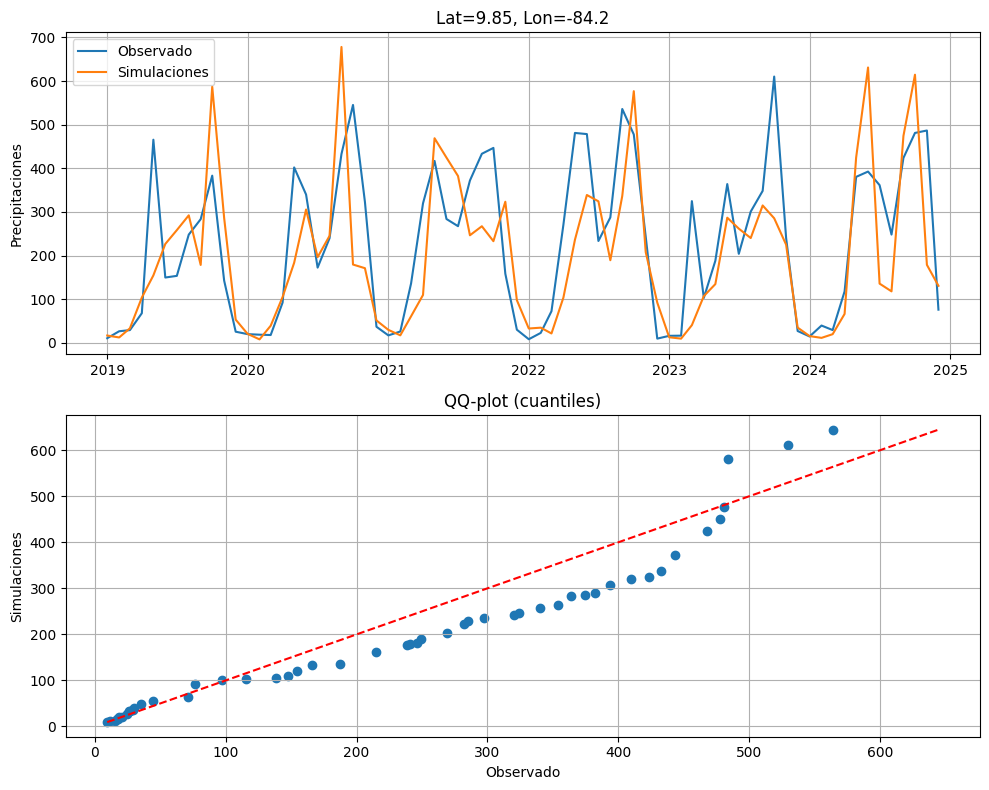

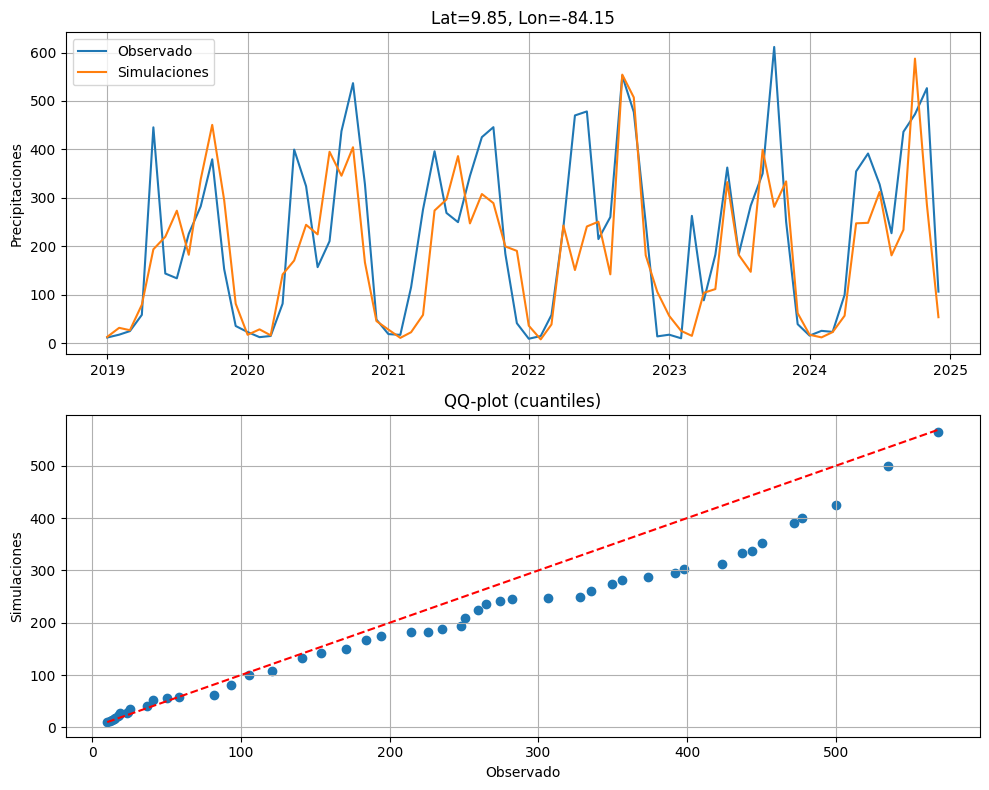

In [46]:
# Testing
plot_modelo_precipitaciones_ubic(datos_santos_test2, ubic_santos, m_testing_santos, nsites_santos, dist_mat_santos, D_corrida, M_corrida, max_plots = 5)

In [35]:
listado_percentiles(dt_errores)

,percentil,umbral_SWD,umbral_MSE
0,0.002,0.158132,0.538260
1,0.005,0.163023,0.577540
2,0.010,0.172187,0.629352
3,0.020,0.195373,0.729689
4,0.025,0.208524,0.785445
5,0.040,0.252071,0.955535
6,0.050,0.283883,1.086013
7,0.100,0.448762,1.448396
8,0.250,0.779769,3.750390


In [39]:
# Percentil 1% sobre TODAS las variantes de modelos
resumen_errores(filtrar_df_por_percentil(dt_errores, 'errorMSE', p = 0.01), sort_by = 'mean_errorMSE')

,modelo,covariables,mean_errorSWD,sd_errorSWD,mean_errorMSE,sd_errorMSE,min_errorSWD,max_errorSWD,min_errorMSE,max_errorMSE,iqr_SWD,iqr_MSE,p25_SWD,p25_MSE,p75_SWD,p75_MSE,n
0,D3,M1,0.166234,0.011500,0.571322,0.038115,0.149013,0.254883,0.440745,0.629326,0.011347,0.059605,0.158624,0.544096,0.169971,0.603702,2725
1,D4,M1,0.169120,0.013885,0.572253,0.037523,0.148951,0.224740,0.446070,0.629344,0.013833,0.058163,0.159720,0.544746,0.173552,0.602909,2595
3,D6,M1,0.166828,0.011049,0.578370,0.033831,0.149302,0.212452,0.491584,0.628680,0.011356,0.052062,0.159294,0.553187,0.170650,0.605249,167
2,D5,M1,0.165826,0.009977,0.579463,0.034629,0.149705,0.212490,0.480219,0.629208,0.011574,0.048011,0.158954,0.558150,0.170528,0.606161,179
5,D8,M1,0.170182,0.013786,0.580989,0.033777,0.150309,0.224361,0.492297,0.629219,0.014506,0.055000,0.160930,0.556352,0.175436,0.611352,161
4,D7,M1,0.168523,0.012707,0.581830,0.034168,0.150169,0.221425,0.491810,0.629344,0.013283,0.049536,0.160049,0.558864,0.173332,0.608399,173


In [41]:
# Percentil 1% asignado entre cada subgrupo de combinaciones de modelos
top1p = filtrar_df_errores_por_percentil_agrupado(dt_errores, "errorMSE", p = 0.01)

top1p.groupby(['modelo', 'covariables'], as_index=False).agg(
    mean_errorSWD=('errorSWD', 'mean'),
    sd_errorSWD = ('errorSWD', 'std'),
    mean_errorMSE = ('errorMSE', 'mean'),
    sd_errorMSE = ('errorMSE', 'std'),
    n = ('errorSWD', 'count')
).sort_values('mean_errorSWD', ascending=True)

,modelo,covariables,mean_errorSWD,sd_errorSWD,mean_errorMSE,sd_errorMSE,n
0,D3,M1,0.162453,0.009626,0.529529,0.022365,1000
1,D4,M1,0.164098,0.010940,0.532404,0.022466,1000
2,D5,M1,0.199459,0.029114,0.742173,0.105522,1000
3,D6,M1,0.207772,0.033870,0.754664,0.111179,1000
4,D7,M1,0.208055,0.033738,0.756498,0.113960,1000
5,D8,M1,0.220942,0.040352,0.765974,0.116500,1000


In [42]:
def revision_parametros_modelo(dt_parametros, D_elegido, M_elegido, error_columna="errorSWD", p=0.01):
    previas_calibradas = ['phi12', 'sigma12', 'phi', 'sigma', 'beta3', 'rho']
    topXp = filtrar_df_errores_por_percentil_agrupado(dt_parametros, error_columna, p=p)
    df_modelo = topXp.loc[(topXp["modelo"] == D_elegido) & (topXp["covariables"] == M_elegido)]

    n = len(previas_calibradas)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
    axs = axs.flatten()

    for i, col in enumerate(previas_calibradas):
        ax = axs[i]
        if col in df_modelo.columns:
            ax.hist(df_modelo[col].dropna(), bins=20, color='tab:blue', edgecolor='black')
            ax.set_title(col, fontsize=10)
            ax.tick_params(labelsize=8)
        else:
            ax.set_visible(False)

    for j in range(i+1, len(axs)):
        axs[j].set_visible(False)

    plt.suptitle("Histogramas de parámetros", fontsize=14)
    plt.tight_layout()
    plt.show()

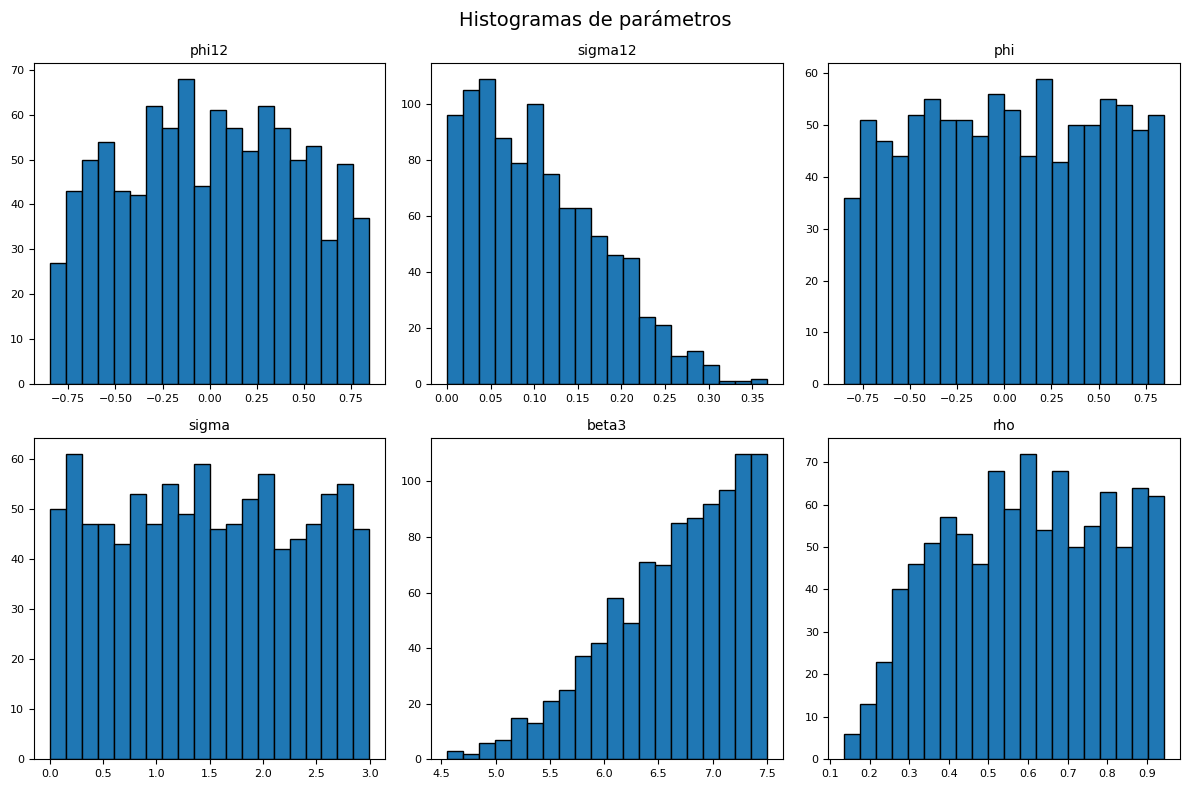

In [45]:
revision_parametros_modelo(dt_errores, 'D3', M_corrida, error_columna = "errorSWD", p = 0.01)

In [44]:
D_corrida

'D4'